# Direct MLP Softmax Portfolio Weight Learner

The MLP does not forecast a covariance matrix. It directly learns long-only portfolio weights using a softmax output layer and is trained to minimize next-month realized portfolio variance.

This notebook is a decision-focused simplification of the earlier covariance-generation / denoising workflow. It reuses the project's processed CRSP covariance datasets, macro feature file, evaluation sleeves, benchmark utilities, and backtest mechanics wherever possible.

## Experimental Setup

| Item | Setting |
|---|---|
| Data | CRSP daily equities |
| Universe | Dynamic market-cap top 500 |
| Sleeve size | 10 same-industry stocks |
| Lookback | 126 trading days |
| Holding period | 21 trading days |
| Train | 2000-2013 |
| Validation | 2014-2020 |
| Test | 2021-2025 |
| Features | Cholesky covariance features + macro features |

Validation selection uses only annualized realized portfolio volatility over 2014-2020. Test evaluation is only performed after selecting the configuration.

In [1]:
from __future__ import annotations

import itertools
import os
import json
import math
import pickle
import random
import sys
import time
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.backtest import run_one_rebalance
from src.benchmarks import equal_weight, ledoit_wolf_linear_gmv
from src.covariance import build_covariance_pair
from src.gmv import solve_long_only_gmv
from src.groups import get_sleeve_permnos
from src.metrics import (
    annualized_return,
    annualized_volatility,
    cvar_95,
    maximum_drawdown,
    sharpe_ratio,
    volatility_reduction_vs_sample_gmv,
)
from src.turnover import apply_transaction_costs
from src.utils import get_device, set_global_seed

pd.set_option("display.max_columns", 100)
set_global_seed(42)
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = get_device()
device

device(type='mps')

## Runtime Controls

By default this notebook uses the smaller grid requested in the task. Set `RUN_FULL_GRID = True` to run the full hyperparameter grid. The test period is not touched until after validation selection.

In [2]:
RUN_FULL_GRID = False
SMOKE_TEST = os.environ.get("MLP_SMOKE_TEST", "0") == "1"
SAVE_ARTIFACTS = not SMOKE_TEST

LOOKBACK_DAYS = 126
HORIZON_DAYS = 21
SLEEVE_SIZE = 10
TRANSACTION_COST_BPS = 10.0

TRAIN_START, TRAIN_END = pd.Timestamp("2000-01-01"), pd.Timestamp("2013-12-31")
VAL_START, VAL_END = pd.Timestamp("2014-01-01"), pd.Timestamp("2020-12-31")
TEST_START, TEST_END = pd.Timestamp("2021-01-01"), pd.Timestamp("2025-12-31")

if RUN_FULL_GRID:
    hidden_dim_grid = [64, 128]
    num_layers_grid = [2, 3]
    lambda_eq_grid = [0.001, 0.01, 0.1]
    learning_rate_grid = [1e-3, 3e-4]
    weight_decay_grid = [0.0, 1e-5]
else:
    hidden_dim_grid = [64, 128]
    num_layers_grid = [2]
    lambda_eq_grid = [0.001, 0.01, 0.1]
    learning_rate_grid = [1e-3]
    weight_decay_grid = [1e-5]

BATCH_SIZE = 256
MAX_EPOCHS = 200
PATIENCE = 20
VALIDATE_EVERY = 5

if SMOKE_TEST:
    hidden_dim_grid = [16]
    num_layers_grid = [1]
    lambda_eq_grid = [0.01]
    learning_rate_grid = [1e-3]
    weight_decay_grid = [1e-5]
    MAX_EPOCHS = 1
    PATIENCE = 1
    VALIDATE_EVERY = 1

ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "mlp"
SCALER_DIR = PROJECT_ROOT / "artifacts" / "scalers"
RESULTS_DIR = PROJECT_ROOT / "results" / "mlp"
for d in [ARTIFACT_DIR, SCALER_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

## Feature Construction

In [3]:
cholesky_repair_counts = {"adaptive_jitter": 0, "eigenvalue_repair": 0}

def covariance_to_cholesky_features(S: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    """
    Convert a 10x10 covariance matrix into 55 Cholesky lower-triangle features.
    Adaptive jitter and eigenvalue repair are counted for numerical diagnostics.
    """
    S = np.asarray(S, dtype=float)
    S = 0.5 * (S + S.T)
    n = S.shape[0]
    if S.shape != (10, 10):
        raise ValueError(f"Expected 10x10 covariance matrix, got {S.shape}")
    jitter = eps
    for attempt in range(8):
        try:
            L = np.linalg.cholesky(S + jitter * np.eye(n))
            if attempt > 0:
                cholesky_repair_counts["adaptive_jitter"] += 1
            return L[np.tril_indices(n)]
        except np.linalg.LinAlgError:
            jitter *= 10
    eigvals, eigvecs = np.linalg.eigh(S)
    eigvals = np.maximum(eigvals, eps)
    S_repaired = eigvecs @ np.diag(eigvals) @ eigvecs.T
    S_repaired = 0.5 * (S_repaired + S_repaired.T)
    L = np.linalg.cholesky(S_repaired + eps * np.eye(n))
    cholesky_repair_counts["eigenvalue_repair"] += 1
    return L[np.tril_indices(n)]

assert covariance_to_cholesky_features(np.eye(10)).shape == (55,)

In [4]:
def load_npz_split(split: str) -> Dict:
    path = PROJECT_ROOT / "data" / "processed" / f"covariance_pairs_{split}.npz"
    meta_path = path.with_suffix(".meta.parquet")
    data = np.load(path, allow_pickle=False)
    meta = pd.read_parquet(meta_path)
    meta["rebalance_date"] = pd.to_datetime(meta["rebalance_date"])
    if "permno_list" in meta.columns:
        meta["permno_list"] = meta["permno_list"].apply(lambda x: [int(p) for p in str(x).split(",")])
    return {"data": {k: data[k] for k in data.files}, "metadata": meta}

splits = {s: load_npz_split(s) for s in ["train", "validation", "test"]}
for split, obj in splits.items():
    print(split, obj["data"]["condition_raw"].shape, obj["data"]["target_raw"].shape, obj["metadata"]["rebalance_date"].min(), obj["metadata"]["rebalance_date"].max())

train (97674, 10, 10) (97674, 10, 10) 1999-12-31 00:00:00 2013-11-08 00:00:00
validation (2425, 10, 10) (2425, 10, 10) 2013-12-31 00:00:00 2020-11-02 00:00:00
test (1434, 10, 10) (1434, 10, 10) 2020-12-31 00:00:00 2024-11-04 00:00:00


In [5]:
def load_macro_features() -> pd.DataFrame:
    macro_path = PROJECT_ROOT / "data" / "interim" / "macro_features.parquet"
    if not macro_path.exists():
        raise FileNotFoundError(f"Macro feature file not found: {macro_path}")
    macro = pd.read_parquet(macro_path)
    if "date" in macro.columns:
        macro["date"] = pd.to_datetime(macro["date"])
        macro = macro.set_index("date")
    else:
        macro.index = pd.to_datetime(macro.index)
        macro.index.name = "date"
    macro = macro.sort_index()
    macro = macro.replace([np.inf, -np.inf], np.nan)
    macro = macro.ffill()
    return macro

macro_df = load_macro_features()
macro_feature_names = list(macro_df.columns)
print(f"Loaded {len(macro_feature_names)} macro features:", macro_feature_names)
macro_df.tail()

Loaded 4 macro features: ['log_mkt_var_21d', 'log_mkt_var_126d', 'mkt_ret_21d', 'avg_pairwise_corr_126d']


,log_mkt_var_21d,log_mkt_var_126d,mkt_ret_21d,avg_pairwise_corr_126d
date,,,,
2024-12-24,-8.876121,-8.693433,-0.014569,0.049149
2024-12-26,-8.819689,-8.678651,-0.010311,0.049806
2024-12-27,-8.816811,-8.677271,-0.011535,0.049131
2024-12-30,-8.828977,-8.681352,-0.016057,0.047038
2024-12-31,-8.865822,-8.682641,-0.026330,0.046874


In [6]:
def macro_asof_for_dates(dates: pd.Series, macro: pd.DataFrame) -> pd.DataFrame:
    original_order = pd.DataFrame({"_order": np.arange(len(dates)), "rebalance_date": pd.to_datetime(dates)})
    left = original_order.sort_values("rebalance_date")
    right = macro.reset_index().rename(columns={macro.index.name or "index": "date"}).sort_values("date")
    merged = pd.merge_asof(left, right, left_on="rebalance_date", right_on="date", direction="backward")
    merged = merged.sort_values("_order")
    return merged[macro.columns].reset_index(drop=True)

def build_cholesky_feature_matrix(covariances: np.ndarray) -> np.ndarray:
    X_cov = np.vstack([covariance_to_cholesky_features(S) for S in covariances])
    assert X_cov.shape[1] == 55
    return X_cov

def build_raw_feature_matrix(split: str) -> Tuple[np.ndarray, pd.DataFrame]:
    data = splits[split]["data"]
    meta = splits[split]["metadata"].copy()
    X_cov = build_cholesky_feature_matrix(data["condition_raw"])
    macro_aligned = macro_asof_for_dates(meta["rebalance_date"], macro_df)
    X_macro = macro_aligned.to_numpy(dtype=float)
    X = np.concatenate([X_cov, X_macro], axis=1)
    assert X.shape[1] == 55 + len(macro_feature_names)
    return X, macro_aligned

X_raw = {}
macro_aligned = {}
for split in ["train", "validation", "test"]:
    X_raw[split], macro_aligned[split] = build_raw_feature_matrix(split)
    print(split, X_raw[split].shape, "macro missing cells:", int(macro_aligned[split].isna().sum().sum()))

print("Cholesky repair summary:", cholesky_repair_counts)

train (97674, 59) macro missing cells: 0
validation (2425, 59) macro missing cells: 0
test (1434, 59) macro missing cells: 0
Cholesky repair summary: {'adaptive_jitter': 0, 'eigenvalue_repair': 0}


In [7]:
train_medians = pd.DataFrame(X_raw["train"]).median(axis=0).to_numpy()

def fill_with_train_medians(X: np.ndarray) -> np.ndarray:
    X = np.asarray(X, dtype=float).copy()
    rows, cols = np.where(~np.isfinite(X))
    if len(rows):
        X[rows, cols] = train_medians[cols]
    return X

X_filled = {split: fill_with_train_medians(X_raw[split]) for split in X_raw}
feature_scaler = StandardScaler()
feature_scaler.fit(X_filled["train"])
X_scaled = {split: feature_scaler.transform(X_filled[split]) for split in X_filled}

if SAVE_ARTIFACTS:
    with open(SCALER_DIR / "mlp_feature_scaler.pkl", "wb") as fh:
        pickle.dump(feature_scaler, fh)
    with open(SCALER_DIR / "mlp_macro_feature_names.json", "w") as fh:
        json.dump(macro_feature_names, fh, indent=2)

print("Feature scaler fit rows:", X_filled["train"].shape[0])
print("Final input dim:", X_scaled["train"].shape[1])
assert X_scaled["train"].shape[1] == 55 + len(macro_feature_names)

Feature scaler fit rows: 97674
Final input dim: 59


## Dataset Construction

In [8]:
class MLPPortfolioDataset(Dataset):
    def __init__(self, X, future_covs, metadata=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.future_covs = torch.tensor(future_covs, dtype=torch.float32)
        self.metadata = metadata
        assert self.future_covs.ndim == 3 and self.future_covs.shape[1:] == (10, 10)
        assert len(self.X) == len(self.future_covs)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.future_covs[idx]

future_covs = {split: splits[split]["data"]["target_raw"] for split in splits}
datasets = {split: MLPPortfolioDataset(X_scaled[split], future_covs[split], splits[split]["metadata"]) for split in ["train", "validation", "test"]}
train_loader = DataLoader(datasets["train"], batch_size=BATCH_SIZE, shuffle=True)

summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "observations": [len(datasets[s]) for s in ["train", "validation", "test"]],
    "first_rebalance_date": [splits[s]["metadata"]["rebalance_date"].min() for s in ["train", "validation", "test"]],
    "last_rebalance_date": [splits[s]["metadata"]["rebalance_date"].max() for s in ["train", "validation", "test"]],
})
display(summary)
print("Number of macro features:", len(macro_feature_names))
print("Final input dimension:", X_scaled["train"].shape[1])
print("Example feature vector shape:", datasets["train"][0][0].shape)
print("Example future covariance shape:", datasets["train"][0][1].shape)

assert splits["train"]["metadata"]["rebalance_date"].max() <= TRAIN_END
assert splits["validation"]["metadata"]["rebalance_date"].max() <= VAL_END
assert splits["test"]["metadata"]["rebalance_date"].max() <= TEST_END

,split,observations,first_rebalance_date,last_rebalance_date
0,train,97674,1999-12-31,2013-11-08
1,validation,2425,2013-12-31,2020-11-02
2,test,1434,2020-12-31,2024-11-04


Number of macro features: 4
Final input dimension: 59
Example feature vector shape: torch.Size([59])
Example future covariance shape: torch.Size([10, 10])


## MLP Architecture

In [9]:
class MLPWeightModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.0):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for _ in range(num_layers):
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.SiLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, 10))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        logits = self.net(x)
        weights = torch.softmax(logits, dim=-1)
        return weights

input_dim = X_scaled["train"].shape[1]
model_check = MLPWeightModel(input_dim=input_dim, hidden_dim=64, num_layers=2).to(device)
batch_x, _ = next(iter(train_loader))
with torch.no_grad():
    weights = model_check(batch_x[:8].to(device))
assert weights.shape[-1] == 10
assert torch.all(weights >= 0)
assert torch.allclose(weights.sum(dim=-1), torch.ones(weights.shape[0], device=weights.device), atol=1e-5)
weights[:2].cpu().numpy()

array([[0.09787684, 0.10811932, 0.09855629, 0.10564109, 0.09853785,
        0.09948239, 0.10331553, 0.09407651, 0.09332066, 0.10107348],
       [0.10249931, 0.10777508, 0.10771493, 0.10807015, 0.08670425,
        0.09073057, 0.105763  , 0.0974675 , 0.09982259, 0.09345267]],
      dtype=float32)

## Training Loss

The training objective is:

\[
L = w^	op S_{future} w + \lambda_{eq}\lVert w-w^{EW}
Vert_2^2
\]

The realized 21-day future covariance is used only inside the loss. The MLP itself does not forecast or denoise covariance matrices.

In [10]:
def portfolio_variance_loss(weights: torch.Tensor, future_cov: torch.Tensor, lambda_eq: float) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    var = torch.einsum("bi,bij,bj->b", weights, future_cov, weights)
    loss_var = var.mean()
    equal_weight_tensor = torch.full_like(weights, 1.0 / weights.shape[1])
    loss_eq = ((weights - equal_weight_tensor) ** 2).sum(dim=1).mean()
    loss = loss_var + lambda_eq * loss_eq
    return loss, loss_var, loss_eq

def train_one_epoch(model, train_loader, optimizer, lambda_eq, device):
    model.train()
    total_loss = total_var_loss = total_eq_loss = n_obs = 0
    for X_batch, future_cov_batch in train_loader:
        X_batch = X_batch.to(device)
        future_cov_batch = future_cov_batch.to(device)
        weights = model(X_batch)
        loss, loss_var, loss_eq = portfolio_variance_loss(weights, future_cov_batch, lambda_eq)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        batch_size = X_batch.shape[0]
        total_loss += loss.item() * batch_size
        total_var_loss += loss_var.item() * batch_size
        total_eq_loss += loss_eq.item() * batch_size
        n_obs += batch_size
    return {"loss": total_loss / n_obs, "loss_var": total_var_loss / n_obs, "loss_eq": total_eq_loss / n_obs}

## Validation Backtest Utilities

In [11]:
def load_backtest_inputs():
    interim = PROJECT_ROOT / "data" / "interim"
    crsp = pd.read_parquet(interim / "cleaned_crsp_daily.parquet")
    crsp["date"] = pd.to_datetime(crsp["date"])
    cal = pd.read_parquet(interim / "trading_calendar.parquet")
    trading_dates = pd.DatetimeIndex(pd.to_datetime(cal["date"]).sort_values())
    reb = pd.read_parquet(interim / "rebalance_dates.parquet")
    reb["rebalance_date"] = pd.to_datetime(reb["rebalance_date"])
    sleeves = pd.read_parquet(interim / "evaluation_sleeves.parquet")
    sleeves["rebalance_date"] = pd.to_datetime(sleeves["rebalance_date"])
    return crsp, trading_dates, reb, sleeves

crsp_df, trading_dates, rebalance_df, evaluation_sleeves = load_backtest_inputs()
val_dates = sorted(rebalance_df.loc[rebalance_df["split"] == "validation", "rebalance_date"].tolist())
test_dates = sorted(rebalance_df.loc[rebalance_df["split"] == "test", "rebalance_date"].tolist())
if SMOKE_TEST:
    val_dates = val_dates[:2]
    test_dates = test_dates[:2]

print(len(val_dates), val_dates[0], val_dates[-1])
print(len(test_dates), test_dates[0], test_dates[-1])

83 2013-12-31 00:00:00 2020-11-02 00:00:00
47 2020-12-31 00:00:00 2024-11-04 00:00:00


In [12]:
def metadata_feature_frame(split: str) -> pd.DataFrame:
    meta = splits[split]["metadata"].copy()
    meta["row_idx"] = np.arange(len(meta))
    id_col = "sleeve_id" if "sleeve_id" in meta.columns else "group_id"
    return meta[["row_idx", "rebalance_date", id_col, "permno_list"]].rename(columns={id_col: "sleeve_id"})

val_feature_meta = metadata_feature_frame("validation")
test_feature_meta = metadata_feature_frame("test")

for split, fm in [("validation", val_feature_meta), ("test", test_feature_meta)]:
    key_count = fm.groupby(["rebalance_date", "sleeve_id"]).size().max()
    assert key_count == 1
    print(split, fm.shape)

validation (2425, 4)
test (1434, 4)


In [13]:
def predict_mlp_weights_for_split(model: nn.Module, split: str, batch_size: int = 4096) -> np.ndarray:
    model.eval()
    X = torch.tensor(X_scaled[split], dtype=torch.float32)
    out = []
    with torch.no_grad():
        for start in range(0, len(X), batch_size):
            w = model(X[start:start + batch_size].to(device)).cpu().numpy()
            out.append(w)
    W = np.vstack(out)
    assert W.shape == (len(X), 10)
    assert np.all(W >= -1e-7)
    assert np.allclose(W.sum(axis=1), 1.0, atol=1e-5)
    return W

def run_split_backtest_from_weight_rows(split: str, weight_rows: np.ndarray, dates: List[pd.Timestamp], cost_bps: float = TRANSACTION_COST_BPS) -> Dict:
    feature_meta = metadata_feature_frame(split)
    feature_meta = feature_meta.copy()
    feature_meta["weights"] = list(weight_rows)
    by_key = {(r.rebalance_date, int(r.sleeve_id)): (np.asarray(r.weights), list(r.permno_list)) for r in feature_meta.itertuples()}

    all_gross, all_weights, all_turnovers, rebalance_indices = [], [], [], []
    previous_drifted = None
    for date in dates:
        date_sleeves = evaluation_sleeves[evaluation_sleeves["rebalance_date"] == date]
        sleeve_wts, sleeve_perms = {}, {}
        for sid in date_sleeves["sleeve_id"].unique():
            key = (date, int(sid))
            if key not in by_key:
                continue
            sleeve_wts[int(sid)], sleeve_perms[int(sid)] = by_key[key]
        if not sleeve_wts:
            continue
        daily_rets, agg_wts, drifted, turnover = run_one_rebalance(
            sleeve_weights=sleeve_wts,
            sleeve_permnos=sleeve_perms,
            crsp_df=crsp_df,
            trading_dates=trading_dates,
            rebalance_date=date,
            horizon_days=HORIZON_DAYS,
            previous_drifted_weights=previous_drifted,
        )
        if not daily_rets:
            continue
        assert abs(sum(agg_wts.values()) - 1.0) < 1e-6
        rebalance_indices.append(len(all_gross))
        all_gross.extend(daily_rets)
        all_weights.append((date, agg_wts))
        all_turnovers.append((date, turnover))
        previous_drifted = drifted

    net = apply_transaction_costs(all_gross, rebalance_indices, [x[1] for x in all_turnovers], cost_bps=cost_bps)
    return {"gross_returns": all_gross, "net_returns": net, "weights": all_weights, "turnovers": all_turnovers, "rebalance_indices": rebalance_indices}

def validation_vol_for_model(model: nn.Module) -> float:
    W = predict_mlp_weights_for_split(model, "validation")
    bt = run_split_backtest_from_weight_rows("validation", W, val_dates, cost_bps=0.0)
    return annualized_volatility(bt["gross_returns"])

## Training and Validation

In [14]:
grid = list(itertools.product(hidden_dim_grid, num_layers_grid, lambda_eq_grid, learning_rate_grid, weight_decay_grid))
print(f"Configurations: {len(grid)}")
print(grid[:5])

Configurations: 6
[(64, 2, 0.001, 0.001, 1e-05), (64, 2, 0.01, 0.001, 1e-05), (64, 2, 0.1, 0.001, 1e-05), (128, 2, 0.001, 0.001, 1e-05), (128, 2, 0.01, 0.001, 1e-05)]


In [15]:
def train_candidate(config: Dict) -> Tuple[nn.Module, pd.DataFrame, float]:
    model = MLPWeightModel(input_dim=input_dim, hidden_dim=config["hidden_dim"], num_layers=config["num_layers"], dropout=0.0).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"], weight_decay=config["weight_decay"])
    best_state = None
    best_val_vol = np.inf
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, MAX_EPOCHS + 1):
        train_metrics = train_one_epoch(model, train_loader, optimizer, config["lambda_eq"], device)
        row = {"epoch": epoch, **train_metrics, "validation_annualized_volatility": np.nan}

        if epoch == 1 or epoch % VALIDATE_EVERY == 0 or epoch == MAX_EPOCHS:
            val_vol = validation_vol_for_model(model)
            row["validation_annualized_volatility"] = val_vol
            if val_vol < best_val_vol - 1e-10:
                best_val_vol = val_vol
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += VALIDATE_EVERY

        history.append(row)
        if epochs_without_improvement >= PATIENCE:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history), best_val_vol

validation_rows = []
training_histories = {}
best = {"validation_annualized_volatility": np.inf, "model": None, "config": None, "history": None}

for i, (hidden_dim, num_layers, lambda_eq, lr, wd) in enumerate(grid, start=1):
    config = {"hidden_dim": hidden_dim, "num_layers": num_layers, "lambda_eq": lambda_eq, "learning_rate": lr, "weight_decay": wd}
    print(f"[{i}/{len(grid)}] {config}")
    start = time.time()
    model, history, val_vol = train_candidate(config)
    elapsed = time.time() - start
    row = {**config, "validation_annualized_volatility": val_vol, "epochs_run": int(history["epoch"].max()), "seconds": elapsed}
    validation_rows.append(row)
    training_histories[str(config)] = history
    display(pd.DataFrame(validation_rows).sort_values("validation_annualized_volatility").head())
    if val_vol < best["validation_annualized_volatility"]:
        best = {"validation_annualized_volatility": val_vol, "model": model, "config": config, "history": history}

validation_results = pd.DataFrame(validation_rows).sort_values("validation_annualized_volatility")
display(validation_results)
print("Selected configuration:", best["config"])
print("Selected validation annualized volatility:", best["validation_annualized_volatility"])

if SAVE_ARTIFACTS:
    validation_results.to_csv(RESULTS_DIR / "validation_grid_results.csv", index=False)
    torch.save({"model_state_dict": best["model"].state_dict(), "config": best["config"], "input_dim": input_dim, "macro_feature_names": macro_feature_names}, ARTIFACT_DIR / "selected_mlp_model.pt")

[1/6] {'hidden_dim': 64, 'num_layers': 2, 'lambda_eq': 0.001, 'learning_rate': 0.001, 'weight_decay': 1e-05}


,hidden_dim,num_layers,lambda_eq,learning_rate,weight_decay,validation_annualized_volatility,epochs_run,seconds
0,64,2,0.001,0.001,0.00001,0.180517,55,288.198753


[2/6] {'hidden_dim': 64, 'num_layers': 2, 'lambda_eq': 0.01, 'learning_rate': 0.001, 'weight_decay': 1e-05}


,hidden_dim,num_layers,lambda_eq,learning_rate,weight_decay,validation_annualized_volatility,epochs_run,seconds
0,64,2,0.001,0.001,0.00001,0.180517,55,288.198753
1,64,2,0.010,0.001,0.00001,0.180757,25,138.758317


[3/6] {'hidden_dim': 64, 'num_layers': 2, 'lambda_eq': 0.1, 'learning_rate': 0.001, 'weight_decay': 1e-05}


...

,hidden_dim,num_layers,lambda_eq,learning_rate,weight_decay,validation_annualized_volatility,epochs_run,seconds
0,64,2,0.001,0.001,0.00001,0.180517,55,288.198753
3,128,2,0.001,0.001,0.00001,0.180545,30,180.557455
4,128,2,0.010,0.001,0.00001,0.180751,20,113.064788
1,64,2,0.010,0.001,0.00001,0.180757,25,138.758317
2,64,2,0.100,0.001,0.00001,0.180809,45,226.903786


[6/6] {'hidden_dim': 128, 'num_layers': 2, 'lambda_eq': 0.1, 'learning_rate': 0.001, 'weight_decay': 1e-05}


,hidden_dim,num_layers,lambda_eq,learning_rate,weight_decay,validation_annualized_volatility,epochs_run,seconds
0,64,2,0.001,0.001,0.00001,0.180517,55,288.198753
3,128,2,0.001,0.001,0.00001,0.180545,30,180.557455
4,128,2,0.010,0.001,0.00001,0.180751,20,113.064788
1,64,2,0.010,0.001,0.00001,0.180757,25,138.758317
5,128,2,0.100,0.001,0.00001,0.180808,60,423.269339


,hidden_dim,num_layers,lambda_eq,learning_rate,weight_decay,validation_annualized_volatility,epochs_run,seconds
0,64,2,0.001,0.001,0.00001,0.180517,55,288.198753
3,128,2,0.001,0.001,0.00001,0.180545,30,180.557455
4,128,2,0.010,0.001,0.00001,0.180751,20,113.064788
1,64,2,0.010,0.001,0.00001,0.180757,25,138.758317
5,128,2,0.100,0.001,0.00001,0.180808,60,423.269339
2,64,2,0.100,0.001,0.00001,0.180809,45,226.903786


Selected configuration: {'hidden_dim': 64, 'num_layers': 2, 'lambda_eq': 0.001, 'learning_rate': 0.001, 'weight_decay': 1e-05}
Selected validation annualized volatility: 0.18051661858045864


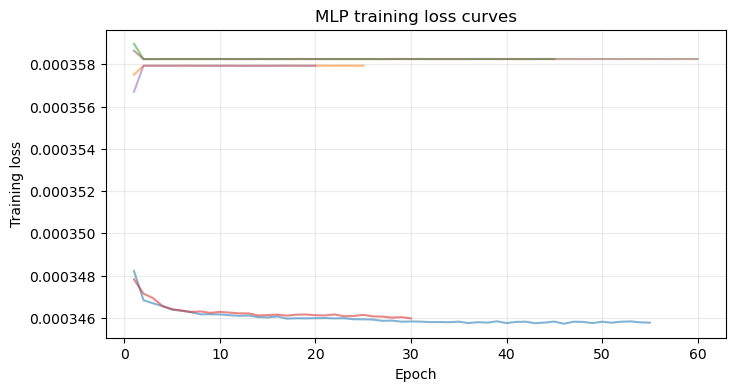

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
for key, hist in training_histories.items():
    ax.plot(hist["epoch"], hist["loss"], alpha=0.55)
ax.set_title("MLP training loss curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Training loss")
ax.grid(True, alpha=0.25)
plt.show()

## Final Test Comparison

In [17]:
def precompute_sleeve_data(dates: List[pd.Timestamp]) -> Dict[Tuple[pd.Timestamp, int], Dict]:
    out = {}
    for date in dates:
        date_sleeves = evaluation_sleeves[evaluation_sleeves["rebalance_date"] == date]
        for sid in date_sleeves["sleeve_id"].unique():
            permnos = get_sleeve_permnos(date_sleeves, sid)
            result = build_covariance_pair(crsp_df, trading_dates, permnos, date, lookback_days=LOOKBACK_DAYS, horizon_days=HORIZON_DAYS)
            if result is None:
                continue
            S_hist, S_fwd, R_hist, R_fwd = result
            out[(date, int(sid))] = {"permnos": permnos, "S_hist": S_hist, "S_fwd": S_fwd, "R_hist": R_hist, "R_fwd": R_fwd}
    return out

test_sleeve_data = precompute_sleeve_data(test_dates)
print("Test sleeve-date observations:", len(test_sleeve_data))

Test sleeve-date observations: 1434


In [18]:
def ewma_covariance(return_matrix: np.ndarray, lam: float = 0.94) -> np.ndarray:
    R = np.asarray(return_matrix, dtype=float)
    R = R - R.mean(axis=0, keepdims=True)
    T = R.shape[0]
    weights = np.array([(1 - lam) * lam ** (T - 1 - i) for i in range(T)], dtype=float)
    weights = weights / weights.sum()
    cov = (R * weights[:, None]).T @ R
    return 0.5 * (cov + cov.T)

def run_method_backtest(method_name: str, dates: List[pd.Timestamp], weight_fn, cost_bps: float = TRANSACTION_COST_BPS) -> Dict:
    all_gross, all_weights, all_turnovers, rebalance_indices = [], [], [], []
    previous_drifted = None
    for date in dates:
        sleeve_wts, sleeve_perms = weight_fn(date)
        if not sleeve_wts:
            continue
        daily_rets, agg_wts, drifted, turnover = run_one_rebalance(
            sleeve_weights=sleeve_wts,
            sleeve_permnos=sleeve_perms,
            crsp_df=crsp_df,
            trading_dates=trading_dates,
            rebalance_date=date,
            horizon_days=HORIZON_DAYS,
            previous_drifted_weights=previous_drifted,
        )
        if not daily_rets:
            continue
        assert abs(sum(agg_wts.values()) - 1.0) < 1e-6
        rebalance_indices.append(len(all_gross))
        all_gross.extend(daily_rets)
        all_weights.append((date, agg_wts))
        all_turnovers.append((date, turnover))
        previous_drifted = drifted
    net = apply_transaction_costs(all_gross, rebalance_indices, [x[1] for x in all_turnovers], cost_bps=cost_bps)
    return {"method": method_name, "gross_returns": all_gross, "net_returns": net, "weights": all_weights, "turnovers": all_turnovers, "rebalance_indices": rebalance_indices}

def benchmark_weight_fn(kind: str):
    def fn(date):
        date_sleeves = evaluation_sleeves[evaluation_sleeves["rebalance_date"] == date]
        wts, perms = {}, {}
        for sid in date_sleeves["sleeve_id"].unique():
            key = (date, int(sid))
            if key not in test_sleeve_data:
                continue
            data = test_sleeve_data[key]
            if kind == "equal_weight":
                w = equal_weight(len(data["permnos"]))
            elif kind == "sample_covariance_gmv":
                w = solve_long_only_gmv(data["S_hist"])
            elif kind == "ledoit_wolf_gmv":
                w = ledoit_wolf_linear_gmv(data["R_hist"])
            elif kind == "ewma_gmv":
                w = solve_long_only_gmv(ewma_covariance(data["R_hist"]))
            else:
                raise ValueError(kind)
            wts[int(sid)] = w
            perms[int(sid)] = data["permnos"]
        return wts, perms
    return fn

mlp_test_weights = predict_mlp_weights_for_split(best["model"], "test")
mlp_test_bt = run_split_backtest_from_weight_rows("test", mlp_test_weights, test_dates, cost_bps=TRANSACTION_COST_BPS)
mlp_test_bt["method"] = "MLP_Softmax_Weight_Learner"

backtests = {
    "Equal_Weight": run_method_backtest("Equal_Weight", test_dates, benchmark_weight_fn("equal_weight")),
    "Sample_Covariance_GMV": run_method_backtest("Sample_Covariance_GMV", test_dates, benchmark_weight_fn("sample_covariance_gmv")),
    "LedoitWolf_Linear_GMV": run_method_backtest("LedoitWolf_Linear_GMV", test_dates, benchmark_weight_fn("ledoit_wolf_gmv")),
    "EWMA_GMV": run_method_backtest("EWMA_GMV", test_dates, benchmark_weight_fn("ewma_gmv")),
    "MLP_Softmax_Weight_Learner": mlp_test_bt,
}

In [19]:
def weights_to_array_list(weights_records: List[Tuple[pd.Timestamp, Dict[int, float]]]) -> List[np.ndarray]:
    return [np.asarray(list(w.values()), dtype=float) for _, w in weights_records]

def summarize_backtest(name: str, bt: Dict, sample_vol: Optional[float] = None) -> Dict:
    gross = np.asarray(bt["gross_returns"], dtype=float)
    net = np.asarray(bt["net_returns"], dtype=float)
    weight_arrays = weights_to_array_list(bt["weights"])
    hhis = [float(np.sum(w ** 2)) for w in weight_arrays]
    max_weights = [float(np.max(w)) for w in weight_arrays]
    turnovers = [x[1] for x in bt["turnovers"]]
    vol = annualized_volatility(gross)
    return {
        "method": name,
        "annualized_volatility": vol,
        "volatility_reduction_vs_sample_cov_mv": np.nan if sample_vol is None else volatility_reduction_vs_sample_gmv(vol, sample_vol),
        "annualized_return": annualized_return(gross),
        "sharpe_ratio": sharpe_ratio(gross),
        "cvar_95": cvar_95(gross),
        "maximum_drawdown": maximum_drawdown(gross),
        "average_turnover": float(np.mean(turnovers)) if turnovers else np.nan,
        "average_hhi": float(np.mean(hhis)) if hhis else np.nan,
        "average_max_weight": float(np.mean(max_weights)) if max_weights else np.nan,
        "net_return_after_transaction_costs": annualized_return(net),
        "n_daily_returns": len(gross),
        "n_rebalances": len(bt["weights"]),
    }

sample_vol = annualized_volatility(backtests["Sample_Covariance_GMV"]["gross_returns"])
summary_rows = [summarize_backtest(name, bt, sample_vol) for name, bt in backtests.items()]
test_summary = pd.DataFrame(summary_rows).sort_values("annualized_volatility")
display(test_summary)

if SAVE_ARTIFACTS:
    test_summary.to_csv(RESULTS_DIR / "test_comparison_summary.csv", index=False)

,method,annualized_volatility,volatility_reduction_vs_sample_cov_mv,annualized_return,sharpe_ratio,cvar_95,maximum_drawdown,average_turnover,average_hhi,average_max_weight,net_return_after_transaction_costs,n_daily_returns,n_rebalances
3,EWMA_GMV,0.126853,0.003987,0.111018,0.893499,0.018141,-0.183312,0.835998,0.011497,0.028133,0.099939,987,47
1,Sample_Covariance_GMV,0.127361,0.000000,0.105531,0.851553,0.018028,-0.190794,0.436709,0.010348,0.026479,0.099757,987,47
2,LedoitWolf_Linear_GMV,0.131035,-0.028848,0.106528,0.838177,0.018497,-0.197495,0.386479,0.007990,0.021468,0.101411,987,47
4,MLP_Softmax_Weight_Learner,0.173190,-0.359838,0.103274,0.654147,0.024601,-0.255246,0.187004,0.003309,0.005534,0.100798,987,47
0,Equal_Weight,0.173684,-0.363715,0.103232,0.652560,0.024655,-0.256274,0.171447,0.003283,0.003283,0.100962,987,47


In [20]:
existing_summary_path = PROJECT_ROOT / "results" / "test" / "test_performance_summary.csv"
if existing_summary_path.exists():
    existing = pd.read_csv(existing_summary_path)
    display(existing)
else:
    print("No existing results/test/test_performance_summary.csv found; conditional covariance model comparison is skipped in this notebook run.")

No existing results/test/test_performance_summary.csv found; conditional covariance model comparison is skipped in this notebook run.


## Plots

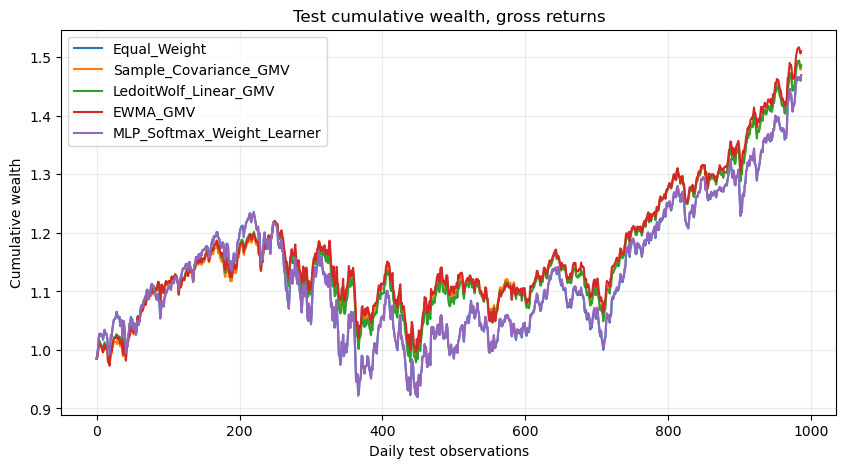

In [21]:
def wealth_series(returns):
    return np.cumprod(1 + np.asarray(returns, dtype=float))

fig, ax = plt.subplots(figsize=(10, 5))
for name, bt in backtests.items():
    ax.plot(wealth_series(bt["gross_returns"]), label=name)
ax.set_title("Test cumulative wealth, gross returns")
ax.set_xlabel("Daily test observations")
ax.set_ylabel("Cumulative wealth")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

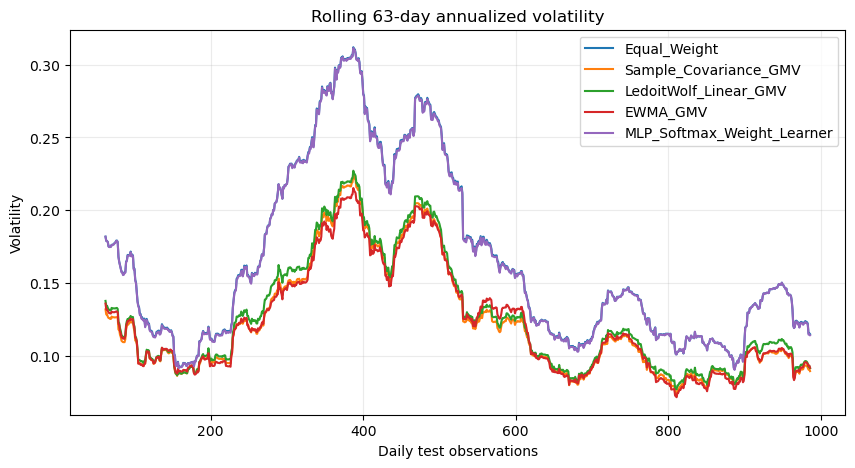

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, bt in backtests.items():
    r = pd.Series(bt["gross_returns"])
    rolling_vol = np.sqrt(252) * r.rolling(63).std()
    ax.plot(rolling_vol, label=name)
ax.set_title("Rolling 63-day annualized volatility")
ax.set_xlabel("Daily test observations")
ax.set_ylabel("Volatility")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

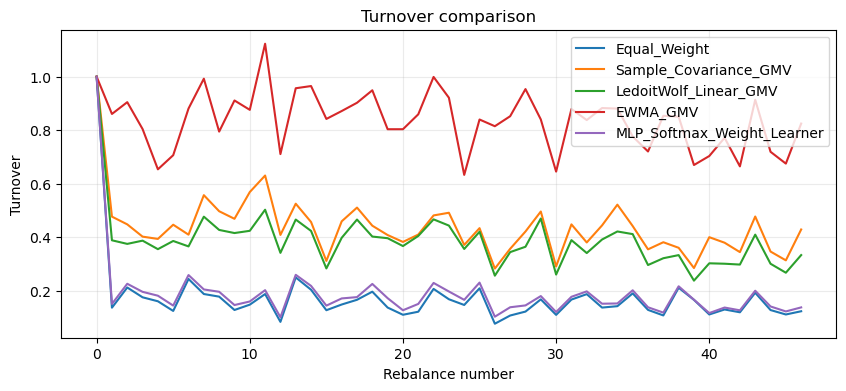

In [23]:
fig, ax = plt.subplots(figsize=(10, 4))
for name, bt in backtests.items():
    ax.plot([x[1] for x in bt["turnovers"]], label=name)
ax.set_title("Turnover comparison")
ax.set_xlabel("Rebalance number")
ax.set_ylabel("Turnover")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

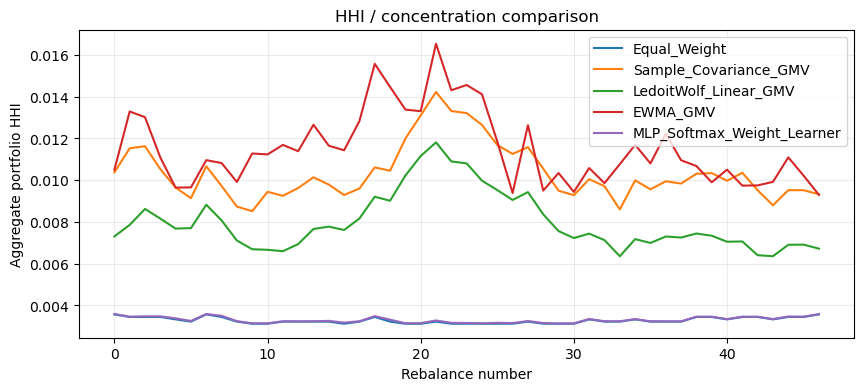

In [24]:
fig, ax = plt.subplots(figsize=(10, 4))
for name, bt in backtests.items():
    hhi = [np.sum(np.asarray(list(w.values())) ** 2) for _, w in bt["weights"]]
    ax.plot(hhi, label=name)
ax.set_title("HHI / concentration comparison")
ax.set_xlabel("Rebalance number")
ax.set_ylabel("Aggregate portfolio HHI")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

## Required Checks

In [25]:
assert X_raw["train"].shape[1] == 55 + len(macro_feature_names)
assert X_scaled["validation"].shape[1] == X_scaled["train"].shape[1]
assert X_scaled["test"].shape[1] == X_scaled["train"].shape[1]
assert feature_scaler.n_features_in_ == X_scaled["train"].shape[1]
assert splits["train"]["metadata"]["rebalance_date"].max() <= TRAIN_END
assert set(val_dates).issubset(set(rebalance_df.loc[rebalance_df["split"] == "validation", "rebalance_date"]))
assert set(test_dates).issubset(set(rebalance_df.loc[rebalance_df["split"] == "test", "rebalance_date"]))
# The existing project assigns splits by complete future holding window, so the first
# validation/test formation date may be in Dec 2013/Dec 2020 while its target window
# belongs to 2014/2021 respectively.
test_feature_meta_active = test_feature_meta[test_feature_meta["rebalance_date"].isin(test_dates)]
test_feature_keys = set(zip(test_feature_meta_active["rebalance_date"], test_feature_meta_active["sleeve_id"].astype(int)))
assert test_feature_keys == set(test_sleeve_data.keys())

for name, bt in backtests.items():
    for _, w in bt["weights"]:
        assert abs(sum(w.values()) - 1.0) < 1e-6, name
print("All checks passed.")

All checks passed.


## Interpretation

Use the table above to keep the interpretation disciplined.

If the MLP has the lowest 2021-2025 annualized volatility among the benchmark set, the result suggests that direct decision-focused weight learning added value beyond explicit covariance estimation in this experimental setting.

If the MLP loses, the result suggests that conventional covariance-based estimators remained more robust than direct neural weight learning, likely because the MLP overfit noisy realized variance targets or failed to learn stable allocation structure.

Either way, this is a sleeve-level long-only volatility experiment, not evidence that the model is universally better across objectives, universes, or transaction-cost regimes.